# 01. Data Overview & Preprocessing

In [ ]:
# Standard data science stack
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency, ks_2samp

# Modeling preprocessing & setup
from sklearn.experimental import enable_iterative_imputer  # Must precede IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

# Machine Learning models
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.svm import SVC
import xgboost as xgb

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

## 1. General Overview

Due to strict institutional privacy regulations, the output of some cells has been cleared to prevent the exposure of re-identifiable patient data (such as specific polypharmacy combinations in free-text fields and internal Subject IDs).

**Summary of the Raw Data Profiling:**
* **Dataset Shape:** The initial dataset consists of 196 rows (patients) and 38 columns (features).
* **Data Types:** 32 numerical variables (`float64`) and 6 categorical/text variables (`object`).
* **Missingness:** All clinical variables exhibited a missing data rate of less than 5%. For instance, `Age` had 192 non-null entries (4 missing), and `ST_Flow` had 195 non-null entries (1 missing).
* **Demographics:** The cohort is 100% female, with an age range from 26 to 94 years (Mean: 58.26).
* **Target Variable:** The `Group` column is perfectly balanced (97 Sjögren vs 99 Controls) and contains 0 missing values.

In [18]:
# ==============================================================================
# 1. EXPLORATORY DATA ANALYSIS (EDA) & DATA PROFILING
# ==============================================================================

# Load the raw clinical dataset from the Excel file.
# Note: 'skiprows=3' is used to bypass the initial metadata/header rows from the hospital's export.
db_ssj = pd.read_excel('./DB_SSJ_Menopausia_HypoSalMed.xlsx', skiprows=3)

# Check the structural dimensions of the dataset (number of patients/rows and features/columns)
db_ssj.shape

# Inspect data types (e.g., float64, object) and evaluate the initial missingness rate per feature
db_ssj.info()

# Generate summary statistics (mean, std, min, max, quartiles) for all numerical variables
db_ssj.describe()

# ==============================================================================
# 2. UNIQUE VALUES INSPECTION (DATA QUALITY CHECK)
# ==============================================================================

# Iterate through all columns to extract their unique values.
"""
for columna in db_ssj.columns:
    valores_unicos = db_ssj[columna].unique()
    print(f"Valores de la columna '{columna}':")
    print(valores_unicos)
    print()
"""

<class 'pandas.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SubjectID               196 non-null    str    
 1   Group                   196 non-null    str    
 2   Age                     192 non-null    float64
 3   Menstrual_status        192 non-null    str    
 4   Genre                   192 non-null    str    
 5   Sport                   192 non-null    float64
 6   Meals/day               191 non-null    float64
 7   Special_Diet            188 non-null    float64
 8   Sugar_Intake            191 non-null    float64
 9   Sugar_between meals     188 non-null    float64
 10  Smoking                 192 non-null    float64
 11  Cigarettes/day          192 non-null    float64
 12  Former_cigarettes/day   191 non-null    float64
 13  Caffeine                191 non-null    float64
 14  Caffeine/day            190 non-null    float64
 15  

'\nfor columna in db_ssj.columns:\n    valores_unicos = db_ssj[columna].unique()\n    print(f"Valores de la columna \'{columna}\':")\n    print(valores_unicos)\n    print()\n'

C:\Users\krist\AppData\Local\Temp\ipykernel_41836\1485643846.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Sjögren", "Control"], y=[sjogren_count, no_sjogren_count], palette=["#C0392B", "#2980B9"])


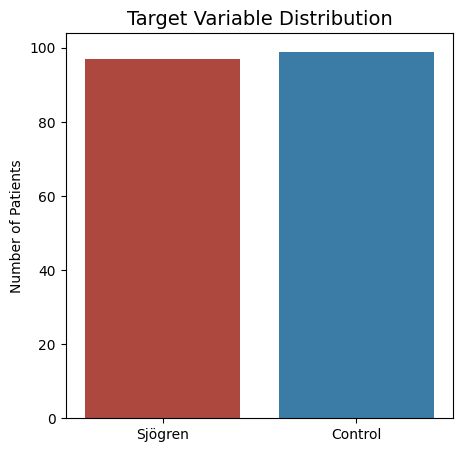

--- Cohort Overview ---
Total patients: 196
Sjögren Syndrome (SjS): 97 (49.5%)
Healthy Controls (No-SjS): 99 (50.5%)



In [13]:
# ==============================================================================
# 3. TARGET VARIABLE DISTRIBUTION (CLASS BALANCE)
# ==============================================================================

# Define the target column
TARGET = 'Group'

total_pacientes = len(db_ssj)
sjogren_count = db_ssj[db_ssj[TARGET] == 'sjj'].shape[0]
no_sjogren_count = db_ssj[db_ssj[TARGET] == 'no-sjj'].shape[0]

porcentaje_sjogren = (sjogren_count / total_pacientes) * 100
porcentaje_no_sjogren = (no_sjogren_count / total_pacientes) * 100

# Plot class balance
plt.figure(figsize=(5, 5))
sns.barplot(x=["Sjögren", "Control"], y=[sjogren_count, no_sjogren_count], palette=["#C0392B", "#2980B9"])
plt.title("Target Variable Distribution", fontsize=14)
plt.ylabel("Number of Patients")
plt.show()

# Print summary
print("--- Cohort Overview ---")
print(f"Total patients: {total_pacientes}")
print(f"Sjögren Syndrome (SjS): {sjogren_count} ({porcentaje_sjogren:.1f}%)")
print(f"Healthy Controls (No-SjS): {no_sjogren_count} ({porcentaje_no_sjogren:.1f}%)\n")

In [19]:
# ==============================================================================
# 4. FEATURE CATEGORIZATION & DISTRIBUTION CHECK
# ==============================================================================

CONTINUOUS = ['Age', 'Meals/day', 'Cigarettes/day', 'Former_cigarettes/day', 
              'Caffeine/day', 'N_Teeth', 'Sound', 'Decay', 'Missing ', 
              'Filling ', 'CAO', 'PROTESIS ', 'N_Oral_mucosa disorder', 
              'SA_Flow (ml/min)', 'ST_Flow (ml/min)']

DISCRETE = ['Menstrual_status', 'Genre', 'Sport', 'Special_Diet', 'Sugar_Intake', 
            'Sugar_between meals', 'Smoking', 'Caffeine', 'Alcohol_drinks', 
            'Cardiovascular', 'Neoplasia', 'Gastrointestinal', 'Diabetes', 
            'Autoinmunes', 'Immunosuppressants', 'Corticosteroids', 'Hyposalivation',
            'Another_medications', 'IPC', 'SA_Hyposalivation', 'ST_Hyposalivation']

# Extract levels for categorical variables
levels = pd.DataFrame(columns=['Count', 'Levels'])
for atributo in DISCRETE:
    valores = list(db_ssj[atributo].dropna().unique())
    levels.loc[atributo] = (len(valores), valores)

# Plotting distributions (Code kept for transparency, outputs cleared for readability/privacy)
"""
for var in DISCRETE:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=var, data=db_ssj, palette='pastel')
    plt.title(f'Distribution of {var}')
    plt.show()

sns.set(style="whitegrid")
for var in CONTINUOUS:
    plt.figure(figsize=(6, 4))
    sns.histplot(db_ssj[var].dropna(), kde=True, color='teal', bins=30)
    plt.title(f'Distribution of {var}', fontsize=12, fontweight='bold')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()
"""

'\nfor var in DISCRETE:\n    plt.figure(figsize=(6, 4))\n    sns.countplot(x=var, data=db_ssj, palette=\'pastel\')\n    plt.title(f\'Distribution of {var}\')\n    plt.show()\n\nsns.set(style="whitegrid")\nfor var in CONTINUOUS:\n    plt.figure(figsize=(6, 4))\n    sns.histplot(db_ssj[var].dropna(), kde=True, color=\'teal\', bins=30)\n    plt.title(f\'Distribution of {var}\', fontsize=12, fontweight=\'bold\')\n    plt.xlabel(var)\n    plt.ylabel(\'Frequency\')\n    plt.show()\n'

C:\Users\krist\AppData\Local\Temp\ipykernel_41836\2191778466.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Age', data=db_ssj, palette=my_pal, width=0.5, boxprops=dict(alpha=0.8))


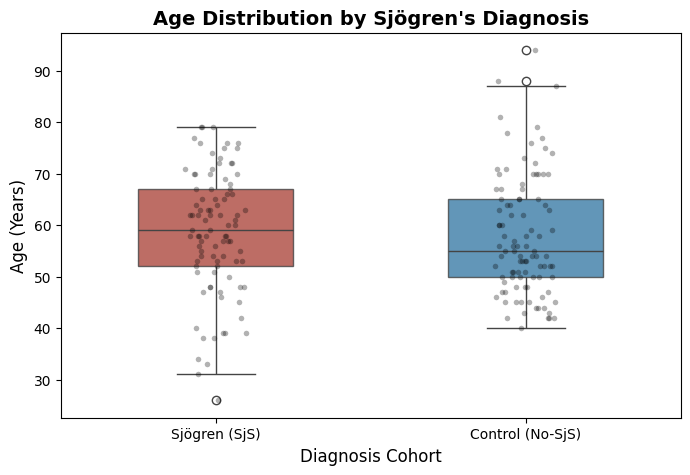

In [12]:
# ==============================================================================
# 6. AGE DISTRIBUTION BY DIAGNOSIS
# ==============================================================================

plt.figure(figsize=(8, 5))

my_pal = {"sjj": "#C0392B", "no-sjj": "#2980B9"}

sns.boxplot(x='Group', y='Age', data=db_ssj, palette=my_pal, width=0.5, boxprops=dict(alpha=0.8))
sns.stripplot(x='Group', y='Age', data=db_ssj, color='black', alpha=0.3, jitter=True, size=4)

plt.title('Age Distribution by Sjögren\'s Diagnosis', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis Cohort', fontsize=12)
plt.ylabel('Age (Years)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Sjögren (SjS)', 'Control (No-SjS)'])

plt.show()

## 2. Preprocessing <a name="preprocesamiento"></a>

Number of duplicated patients: 0
Proportion of the cohort affected by missingness: 14.29%


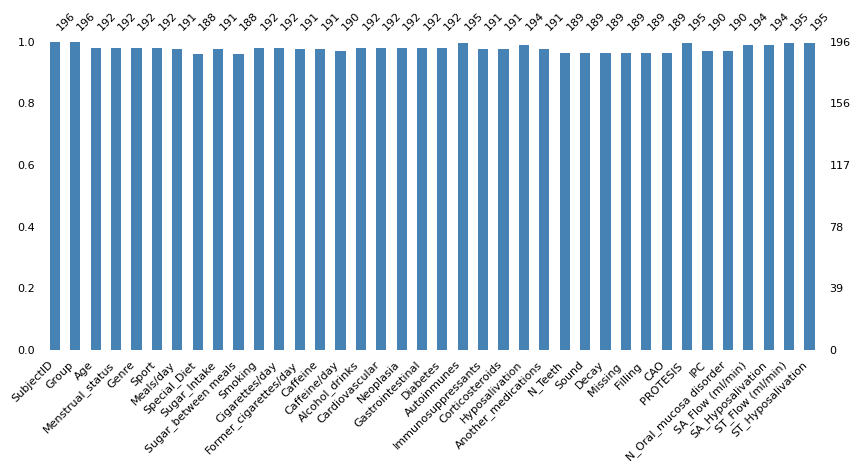

In [16]:
# ==============================================================================
# 7. DATA CLEANING & MISSINGNESS ASSESSMENT
# ==============================================================================

# 7.1. Check for duplicated records
# Verify that each SubjectID is unique to prevent artificial sample size inflation
mask_duplicados = db_ssj['SubjectID'].duplicated(keep=False)
valores_concretos_duplicados = db_ssj.loc[mask_duplicados, 'SubjectID'].unique()
print(f"Number of duplicated patients: {len(valores_concretos_duplicados)}") 
# (Expected output: 0)

# 7.2. Feature-wise missing data evaluation
# Calculate the percentage of missing values per column
missing_percentage = db_ssj.isna().sum() / len(db_ssj) * 100
#print("\nMissing data percentage per feature (>0%):")
#print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

# Visualize data completeness using missingno bar chart
msno.bar(db_ssj, figsize=(10, 4), fontsize=8, color="steelblue")

# 7.3. Row-wise missing data evaluation
# Identify how many patients have AT LEAST ONE missing value across all features.
# This justifies the use of MICE imputation rather than listwise deletion (dropping rows).
pacientes_nulos = db_ssj[db_ssj.isnull().any(axis=1)]
total_nulos = len(pacientes_nulos)
porcentaje_nulos = (total_nulos / len(db_ssj)) * 100

#print(f"\nTotal patients with at least one missing value: {total_nulos}")
print(f"Proportion of the cohort affected by missingness: {porcentaje_nulos:.2f}%")

# 7.4. Zero-Variance feature removal
# The 'Genre' variable is dropped because the cohort is 100% female.
# Features with zero variance provide no informational gain for downstream ML models.
data_limpio = db_ssj.drop(columns=['Genre'])

In [17]:
# ==============================================================================
# 8. DATA TRANSFORMATION & FEATURE ENGINEERING
# ==============================================================================

# --- 8.1. High-Cardinality Text Removal & Variable Renaming ---
# The 'Another_medications' column contains free-text polypharmacy data.
# One-Hot Encoding this would cause a massive dimensionality explosion and risk patient re-identification.
# The clinical essence of this column was already extracted into a binary 'Hyposalivation' flag 
# (indicating if any of the listed drugs are xerogenic).
# Action: We drop the free text and rename the flag for clarity.
data_limpio = data_limpio.drop(columns=['Another_medications'])
data_limpio = data_limpio.rename(columns={'Hyposalivation': 'Hyposalivation_med'})


# --- 8.2. Custom Encoding for Menstrual Status ---
# Standard LabelEncoder replaces NaNs with a class (e.g., 2), which corrupts future imputation.
# Action: We define a custom function that encodes string categories to float but preserves NaNs.
def label_encode_with_nan(series):
    unique_vals = series.dropna().unique()
    mapping = {k: float(v) for v, k in enumerate(unique_vals)}
    return series.map(mapping)

data_limpio["Menstrual_status"] = label_encode_with_nan(data_limpio["Menstrual_status"])
# Encoding Result: 0.0 -> Post-menopausal, 1.0 -> Pre-menopausal


# --- 8.3. Cleaning the Community Periodontal Index (CPI / IPC) ---
# The raw IPC variable contains strings representing clinical exclusion/error codes:
# 'X' = Excluded sextant (clinically non-evaluable)
# '9' = Not recorded (true missing value)
# Action: We replace 'X' and '9' with standard np.nan, then convert the column to numeric.
data_limpio["IPC"] = data_limpio["IPC"].replace({"X": np.nan, "9": np.nan})
data_limpio["IPC"] = pd.to_numeric(data_limpio["IPC"], errors='coerce')


# --- 8.4. Target Variable Encoding ---
# We encode the target 'Group' into a binary integer format and rename it to 'Sjogren'
label_encoder = LabelEncoder()
data_limpio['Group'] = label_encoder.fit_transform(data_limpio['Group'])
data_limpio = data_limpio.rename(columns={'Group': 'Sjogren'})
# Encoding Result: 0 -> Control (no-sjj), 1 -> Sjögren (sjj)

# ==============================================================================
# 9. FINAL DATASET STRUCTURE (PRE-IMPUTATION)
# ==============================================================================
print("--- Final Dataset Info Before Imputation ---")
data_limpio.info()

# Privacy Note: df.head() has been omitted from the output to prevent SubjectID exposure.
print("\nTransformations applied successfully. Ready for MICE imputation.")

--- Final Dataset Info Before Imputation ---
<class 'pandas.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SubjectID               196 non-null    str    
 1   Sjogren                 196 non-null    int64  
 2   Age                     192 non-null    float64
 3   Menstrual_status        192 non-null    float64
 4   Sport                   192 non-null    float64
 5   Meals/day               191 non-null    float64
 6   Special_Diet            188 non-null    float64
 7   Sugar_Intake            191 non-null    float64
 8   Sugar_between meals     188 non-null    float64
 9   Smoking                 192 non-null    float64
 10  Cigarettes/day          192 non-null    float64
 11  Former_cigarettes/day   191 non-null    float64
 12  Caffeine                191 non-null    float64
 13  Caffeine/day            190 non-null    float64
 14  Alcohol_

### 2.1 MICE Imputation

* **Missingness Profile:** While individual features exhibited <5% missingness, 14.3% of the total instances (28 patients) contained at least one missing value. Dropping these rows would introduce bias and reduce statistical power.
* **Imputation Strategy:** Multiple Imputation by Chained Equations (MICE) was applied exclusively to the feature space. The target variable (`Sjogren`) was fully populated and excluded from the imputation matrix to prevent data leakage.
* **Post-Imputation Validation:** Kolmogorov-Smirnov (KS) tests for continuous variables and Chi-Square tests for categorical variables confirmed that the MICE algorithm successfully preserved the original data distributions ($p > 0.05$ for all features).

Applying MICE Imputation...

=== Validation: Continuous Variables (Kolmogorov-Smirnov Test) ===
Age: KS p-value = 1.0000 (Consistent distribution)
Meals/day: KS p-value = 1.0000 (Consistent distribution)
Cigarettes/day: KS p-value = 1.0000 (Consistent distribution)
Former_cigarettes/day: KS p-value = 1.0000 (Consistent distribution)
Caffeine/day: KS p-value = 1.0000 (Consistent distribution)
N_Teeth: KS p-value = 1.0000 (Consistent distribution)
Sound: KS p-value = 1.0000 (Consistent distribution)
Decay: KS p-value = 1.0000 (Consistent distribution)
Missing : KS p-value = 1.0000 (Consistent distribution)
Filling : KS p-value = 1.0000 (Consistent distribution)
CAO: KS p-value = 1.0000 (Consistent distribution)
PROTESIS : KS p-value = 1.0000 (Consistent distribution)
N_Oral_mucosa disorder: KS p-value = 1.0000 (Consistent distribution)
SA_Flow (ml/min): KS p-value = 1.0000 (Consistent distribution)
ST_Flow (ml/min): KS p-value = 1.0000 (Consistent distribution)

=== Validation: Categoric

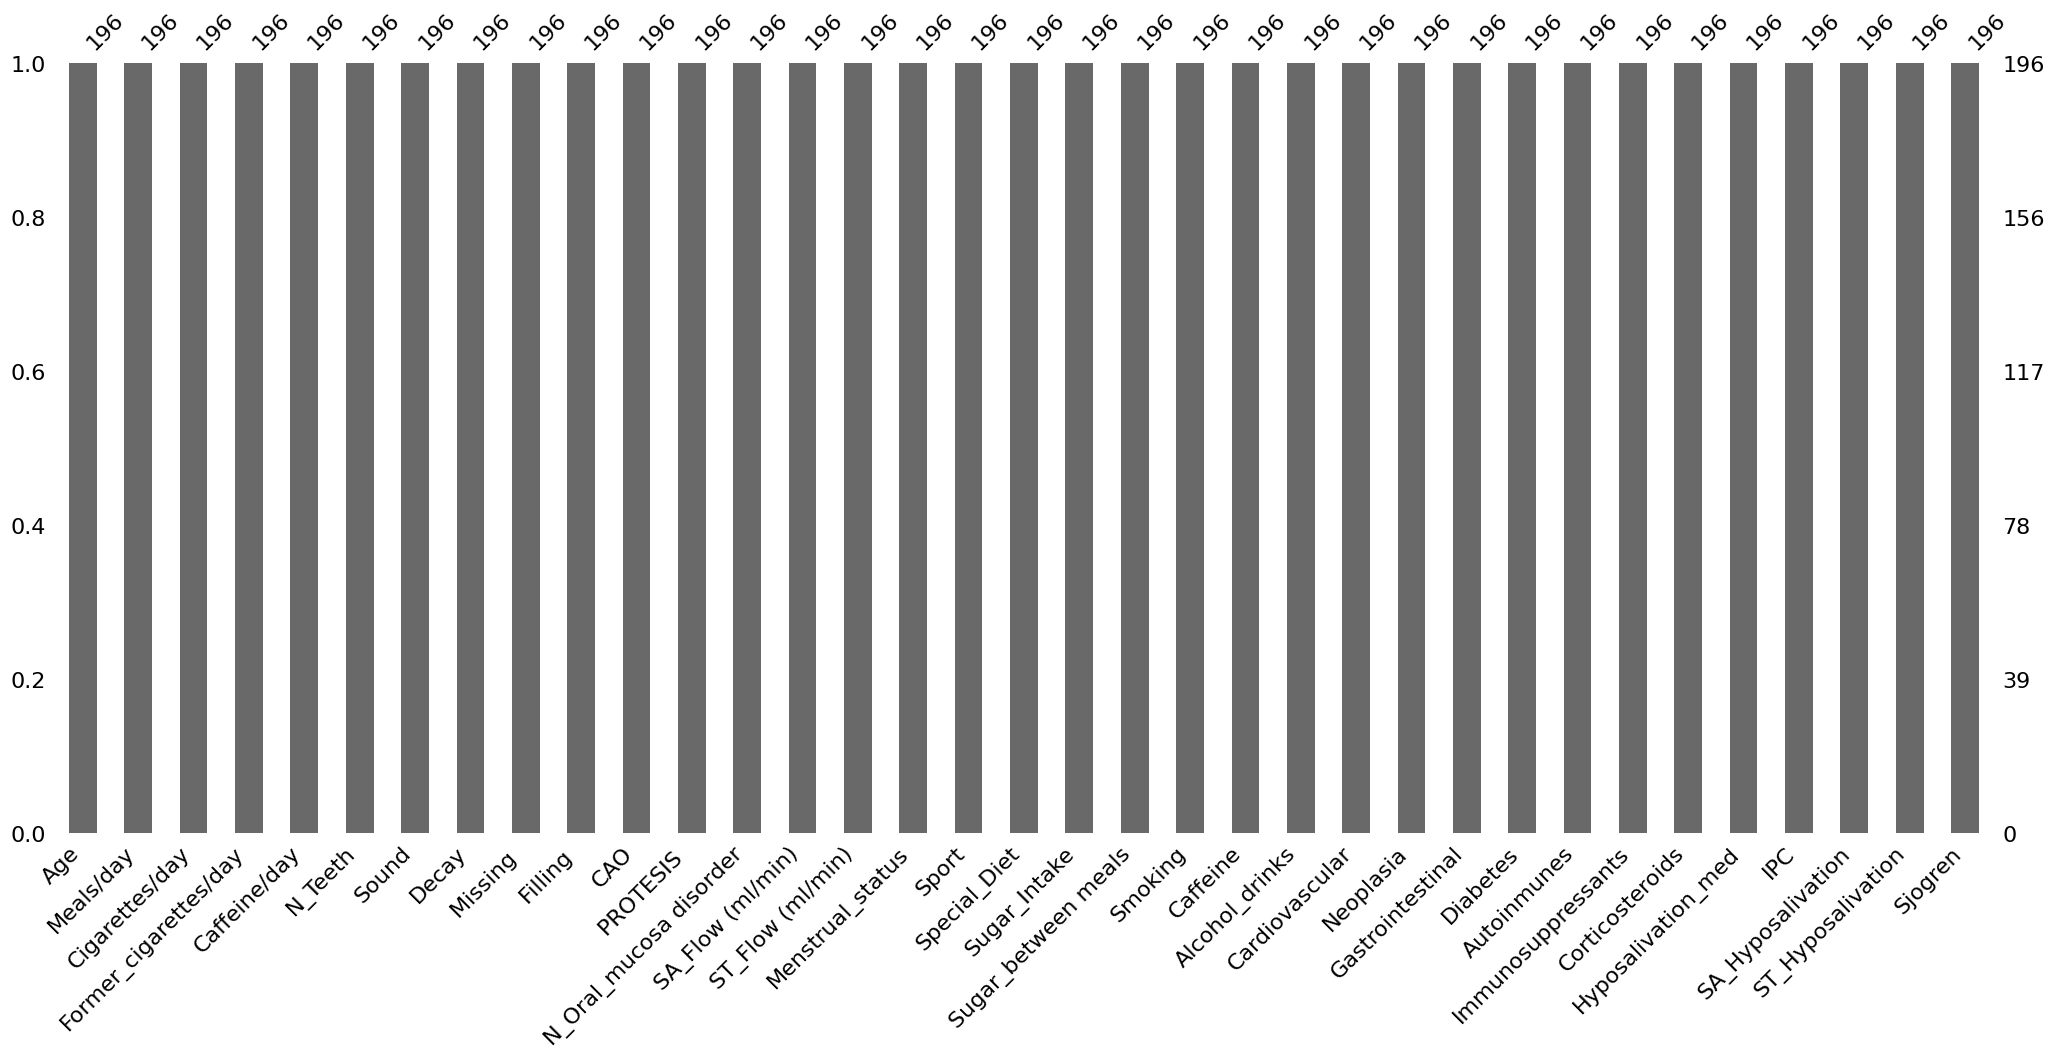

In [25]:
# ==============================================================================
# 10. MISSING DATA IMPUTATION (MICE) & DISTRIBUTION VALIDATION
# ==============================================================================

# Define variable types
TARGET = 'Sjogren'

CONTINUOUS = ['Age', 'Meals/day', 'Cigarettes/day', 'Former_cigarettes/day', 'Caffeine/day', 'N_Teeth', 
              'Sound', 'Decay', 'Missing ', 'Filling ', 'CAO', 'PROTESIS ', 'N_Oral_mucosa disorder', 
              'SA_Flow (ml/min)', 'ST_Flow (ml/min)']

DISCRETE = ['Menstrual_status', 'Sport', 'Special_Diet', 'Sugar_Intake', 'Sugar_between meals', 
            'Smoking', 'Caffeine', 'Alcohol_drinks', 'Cardiovascular', 'Neoplasia', 
            'Gastrointestinal', 'Diabetes', 'Autoinmunes', 'Immunosuppressants', 
            'Corticosteroids', 'Hyposalivation_med', 'IPC', 'SA_Hyposalivation', 'ST_Hyposalivation']

# Filter valid columns present in data_limpio
valid_columns = data_limpio.columns
CONTINUOUS = [col for col in CONTINUOUS if col in valid_columns]
DISCRETE = [col for col in DISCRETE if col in valid_columns]
numeric_vars = CONTINUOUS + DISCRETE

# --- 10.1. MICE IMPUTATION ---
print("Applying MICE Imputation...")
imputer = IterativeImputer(random_state=42, max_iter=10)

# Impute only the feature space (excluding target)
data_imputada_array = imputer.fit_transform(data_limpio[numeric_vars])
data_imputada = pd.DataFrame(data_imputada_array, columns=numeric_vars, index=data_limpio.index)

# Post-processing: Round flow variables to 2 decimals, rest to integers
flow_vars = ['SA_Flow (ml/min)', 'ST_Flow (ml/min)']
for col in data_imputada.columns:
    if col in flow_vars:
        data_imputada[col] = data_imputada[col].round(2)
    else:
        data_imputada[col] = data_imputada[col].round().astype(int)

# Safely add the target variable back
data_imputada[TARGET] = data_limpio[TARGET]

# --- 10.2. POST-IMPUTATION VALIDATION (Continuous Variables) ---
print("\n=== Validation: Continuous Variables (Kolmogorov-Smirnov Test) ===")
for var in CONTINUOUS:
    original = data_limpio[var].dropna()
    imputed = data_imputada[var]
    
    stat, p_value = ks_2samp(original, imputed)
    status = "Consistent distribution" if p_value > 0.05 else "⚠️ Warning: Potential shift"
    
    print(f"{var}: KS p-value = {p_value:.4f} ({status})")
    
    # Plotting code available but commented out to keep the notebook output clean
    """
    plt.figure(figsize=(6, 3))
    sns.kdeplot(original, label="Original (Drop-NA)", fill=True)
    sns.kdeplot(imputed, label="Imputed (MICE)", fill=True, linestyle='--')
    plt.title(f'Density Plot: {var}')
    plt.legend()
    plt.show()
    """

# --- 10.3. POST-IMPUTATION VALIDATION (Categorical Variables) ---
print("\n=== Validation: Categorical Variables (Chi-Square Test) ===")
for var in DISCRETE:
    freq_orig = data_limpio[var].value_counts(dropna=True)
    freq_imp = data_imputada[var].value_counts(dropna=True)
    
    union_cats = sorted(set(freq_orig.index) | set(freq_imp.index))
    contingency_table = pd.DataFrame({
        'Original': [freq_orig.get(cat, 0) for cat in union_cats],
        'Imputed': [freq_imp.get(cat, 0) for cat in union_cats]
    })
    
    chi2, p, dof, ex = chi2_contingency(contingency_table.T)
    status = "Consistent distribution" if p > 0.05 else "⚠️ Warning: Potential shift"
    
    print(f"{var}: Chi-square p-value = {p:.4f} ({status})")
    
    # Plotting code available but commented out
    """
    df_freq = pd.DataFrame({'Original': freq_orig / freq_orig.sum(), 'Imputed': freq_imp / freq_imp.sum()}).fillna(0)
    df_freq.plot(kind='bar', figsize=(6,3))
    plt.title(f'Relative Frequencies: {var}')
    plt.show()
    """

# Final completeness check
msno.bar(data_imputada)

# Save the preprocessed dataset
data_imputada.to_csv('ssj_imputed_clean.csv', index=False)
print("\n MICE Imputation complete. Dataset saved.")

### Outlier Detection

 Number of outliers per feature:
Diabetes                  48
Cigarettes/day            38
Smoking                   34
ST_Hyposalivation         34
N_Oral_mucosa disorder    31
Hyposalivation_med        31
Special_Diet              30
Immunosuppressants        26
Gastrointestinal          19
SA_Flow (ml/min)          16
Decay                     15
Missing                   15
N_Teeth                   15
IPC                       14
Neoplasia                 10
Corticosteroids            9
ST_Flow (ml/min)           4
Caffeine/day               1
Meals/day                  1
Age                        1
CAO                        1
dtype: int64

Total patients with at least one outlier: 169


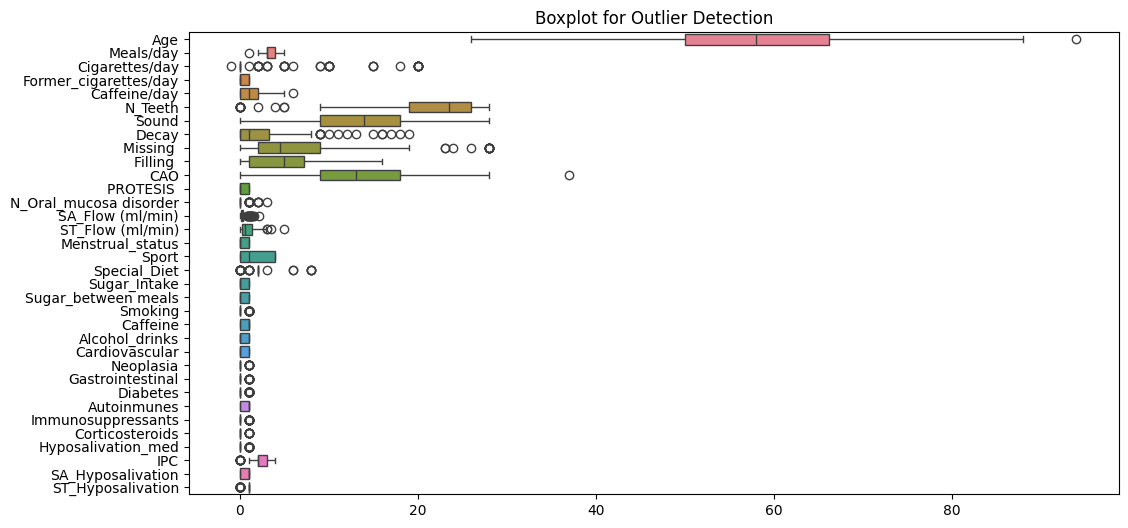

In [29]:
# ==============================================================================
# 11. OUTLIER DETECTION & HANDLING
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical variables (excluding the target 'Sjogren' if present)
numeric_vars = data_imputada.select_dtypes(include='number').columns.tolist()
if 'Sjogren' in numeric_vars:
    numeric_vars.remove('Sjogren')

# 11.1. Calculate IQR (Interquartile Range)
Q1 = data_imputada[numeric_vars].quantile(0.25)
Q3 = data_imputada[numeric_vars].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = (data_imputada[numeric_vars] < lower_bound) | (data_imputada[numeric_vars] > upper_bound)
outliers_count = outliers.sum()

print(" Number of outliers per feature:")
print(outliers_count[outliers_count > 0].sort_values(ascending=False))

# Identify patients with at least one outlier
pacientes_outliers = data_imputada[outliers.any(axis=1)]
print(f"\nTotal patients with at least one outlier: {pacientes_outliers.shape[0]}")

# Visualizing outliers via boxplots is kept in the codebase but output is cleared for readability)
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_imputada[numeric_vars], orient='h')
plt.title("Boxplot for Outlier Detection")
plt.show()

The Interquartile Range (IQR) method identified outliers in several variables (e.g., `Diabetes`, `Smoking`, `Cigarettes/day`). In a clinical context, these are not erroneous data points but rather true extreme values or natural distributions of binary/minority classes. 
* **Decision:** Outliers were **retained** to preserve the true clinical variance of the cohort. To mitigate their impact on distance-based or variance-based algorithms in subsequent steps, the dataset will be scaled using `RobustScaler` prior to Machine Learning modeling.

--- Highly Correlated Feature Pairs (|r| > 0.6) ---
Age <-> Menstrual_status: r = -0.654
Cigarettes/day <-> Smoking: r = 0.820
Caffeine/day <-> Caffeine: r = 0.738
N_Teeth <-> Sound: r = 0.727
N_Teeth <-> Missing : r = -1.000
N_Teeth <-> CAO: r = -0.711
Sound <-> Missing : r = -0.727
Sound <-> CAO: r = -0.915
Missing  <-> CAO: r = 0.711
SA_Flow (ml/min) <-> SA_Hyposalivation: r = -0.692
ST_Flow (ml/min) <-> ST_Hyposalivation: r = -0.772
Autoinmunes <-> Sjogren: r = 0.763


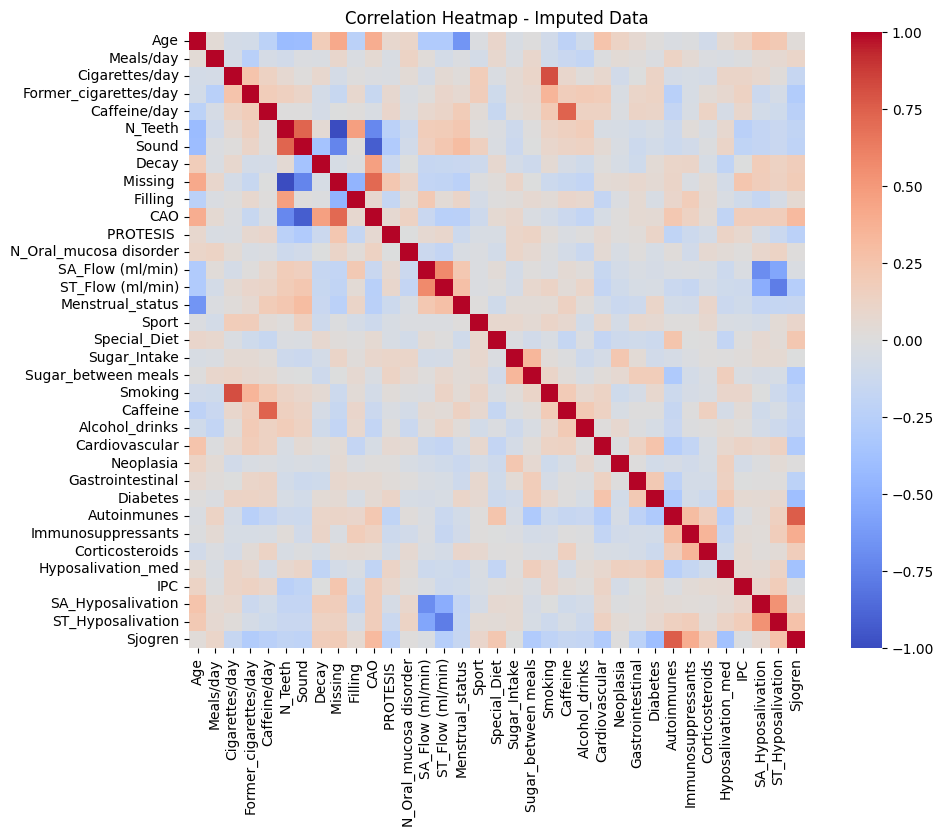

In [32]:
# ==============================================================================
# 12. COLLINEARITY ANALYSIS & DIMENSIONALITY REDUCTION
# ==============================================================================

# Calculate correlation matrix
corr_matrix = data_imputada.corr(numeric_only=True)

# Define threshold for strong correlation
threshold = 0.60
strong_pairs = []

# Loop through the upper triangle of the correlation matrix (naturally skips the diagonal)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > threshold:
            strong_pairs.append((corr_matrix.index[i], corr_matrix.columns[j], corr_val))

print(f"--- Highly Correlated Feature Pairs (|r| > {threshold}) ---")
for var1, var2, corr_val in strong_pairs:
    print(f"{var1} <-> {var2}: r = {corr_val:.3f}")

# Heatmap visualization
plt.figure(figsize=(12, 8))
sns.heatmap(data_imputada.corr(), annot=False, cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Heatmap - Imputed Data")
plt.show()


A Pearson correlation heatmap revealed highly correlated feature pairs (threshold > 0.60). To reduce dimensionality, eliminate redundant information, and prevent multicollinearity issues, the following feature engineering steps were applied:

1. **Zero-Variance & Privacy:** `Genre` (100% Female) and `Another_medications` (free-text) were removed.
2. **Redundant Dental Metrics:** `Decay`, `Missing`, and `Filling` were dropped in favor of the composite `CAO` (DMFT) index, which captures the total accumulated dental damage ($r > 0.71$).
3. **Redundant Salivary Metrics:** Binary indicators `SA_Hyposalivation` and `ST_Hyposalivation` were dropped in favor of the continuous flow rate variables (`SA_Flow` and `ST_Flow`), which provide higher informational granularity.
4. **Redundant Lifestyle/Systemic Metrics:** `Cigarettes/day`, `Caffeine/day`, `Autoinmunes`, and `Immunosuppressants` were removed due to high collinearity with their primary indicator variables or the target itself.
 
**Final Dataset Shape:** The preprocessed, fully imputed, and de-correlated dataset consists of **196 patients and 27 features** (inlcuding the target variable).

In [33]:
# ==============================================================================
# 13. FINAL DATASET EXPORT
# ==============================================================================

cols_to_drop = [
    'Cigarettes/day',
    'Caffeine/day',
    'SA_Hyposalivation',
    'ST_Hyposalivation',
    'Decay',
    'Missing',  
    'Filling',
    'Autoinmunes',
    'Immunosuppressants'
]

# Clean column names to avoid whitespace issues
data_imputada.columns = data_imputada.columns.str.strip()
cols_to_drop = [col.strip() for col in cols_to_drop]

# Drop redundant columns
data_imputada = data_imputada.drop(columns=cols_to_drop)

# Re-insert the SubjectIDs for local analysis
data_imputada.insert(0, 'SubjectID', db_ssj['SubjectID'].values)

# Save the final dataset
data_imputada.to_excel('data_limpio.xlsx', index=False)

print(f"--- Final Dataset Ready ---")
print(f"Shape: {data_imputada.shape}")

--- Final Dataset Ready ---
Shape: (196, 27)
